# Análisis de datos
### Nancy Armua | Brian Talavera 

## Preparación de ambiente 

In [1]:
import pandas as pd
import numpy as np
from pandas.api.types import CategoricalDtype
import matplotlib.pyplot as plt
import seaborn as sns
from utils import plot_histograma

### Fuente del dataset

Dataset recorridos Ecobicis 2023: https://data.buenosaires.gob.ar/dataset/bicicletas-publicas/resource/ff671909-6860-4398-8d0a-8f2389cb2780/download

Dataset ususarios Ecobicis 2023: https://data.buenosaires.gob.ar/dataset/bicicletas-publicas/resource/edb5ed27-8506-43f0-88ce-3e5c0aa1a406/download


#### 1. Cargar datos desde un archivo CSV a un df de Pandas

In [2]:
path = "./dataset/"

df_recorridos = pd.read_csv(path + "trips_2023.csv")
df_usuarios = pd.read_csv(path + "usuarios_ecobici_2023.csv")


/tmp/ipykernel_193034/392836254.py:4: DtypeWarning: Columns (0: edad_usuario) have mixed types. Specify dtype option on import or set low_memory=False.
  df_usuarios = pd.read_csv(path + "usuarios_ecobici_2023.csv")


** A revisar: para el dataset de usuarios, edar_usuario aparentemente contiene datos mixtos.

## Exploración y comprensión de los datos
### Primeras filas de cada dataset


In [3]:
# Mostrar las primeras 5 filas de cada dataset
df_recorridos.head(5)


,Unnamed: 0,Id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,género
0,1,17910696BAEcobici,"1,848",2023-04-24 10:30:10,358BAEcobici,249 - Balbín,2519 Conesa,-58.465586,-34.561486,2023-04-24 11:00:58,278BAEcobici,233 - MONROE,2519 Superi,-58.469813,-34.564122,861866BAEcobici,ICONIC,MALE
1,2,17600256BAEcobici,288,2023-03-22 17:40:55,444BAEcobici,061 - Ministerio de Economia,"Balcarce e Yrigoyen, Hipolito Av.",-58.370716,-34.608936,2023-03-22 17:45:43,3BAEcobici,003 - ADUANA,Moreno & Azopardo,-58.368174,-34.611102,217525BAEcobici,ICONIC,FEMALE
2,3,17255670BAEcobici,"1,103",2023-02-15 23:12:22,280BAEcobici,222 - SIMON BOLIVAR,"1701 Fernandez Moreno, Baldomero",-58.449379,-34.633528,2023-02-15 23:30:45,280BAEcobici,222 - SIMON BOLIVAR,"1701 Fernandez Moreno, Baldomero",-58.449379,-34.633528,954201BAEcobici,ICONIC,MALE
3,4,17996972BAEcobici,"1,165",2023-05-03 11:00:20,273BAEcobici,223 - GAINZA,"494 Gainza, Martin De, Gral.",-58.446751,-34.616758,2023-05-03 11:19:45,367BAEcobici,287 - Belaustegui,"Belaustegui, Luis, Dr. 2890",-58.477209,-34.616212,179414BAEcobici,ICONIC,MALE
4,5,17148836BAEcobici,378,2023-02-06 06:50:58,65BAEcobici,065 - Julián Álvarez,3822 Guemes,-58.415787,-34.587312,2023-02-06 06:57:16,14BAEcobici,014 - Pacifico,"Santa Fe Av. & Bullrich, Int. Av.",-58.426387,-34.577424,8098BAEcobici,ICONIC,MALE


In [4]:
df_usuarios.head(5)

,ID_usuario,genero_usuario,edad_usuario,fecha_alta,hora_alta,Customer.Has.Dni..Yes...No.
0,1083476,MALE,20,2023-12-31,19:24:57,Yes
1,1083080,FEMALE,18,2023-12-31,00:05:03,Yes
2,1083163,OTHER,27,2023-12-31,10:16:12,No
3,1083435,MALE,24,2023-12-31,17:42:11,Yes
4,1083376,OTHER,32,2023-12-31,16:16:15,No


#### Descripción del dataset de usuarios


| Variable | Descripción | Tipo |
| --- | --- | --- |
| `ID_usuario` | Identificador único del usuario | Categórica nominal |
| `genero_usuario` | Género autopercibido declarado por el usuario (`MALE`, `FEMALE`, `OTHER`) | Categórica nominal |
| `edad_usuario` | Edad del usuario en años | Cuantitativa discreta |
| `fecha_alta` | Fecha de alta del usuario en el sistema | Categórica / Cuantitativa |
| `hora_alta` | Hora de alta del usuario en el sistema | Cuantitativa continua |
| `Customer.Has.Dni..Yes...No.` | Indica si el usuario cuenta con DNI registrado (`Yes`/`No`) | Categórica nominal |


#### Descripción del dataset de recorridos

| Variable | Descripción | Tipo |
| --- | --- | --- |
| `Id_recorrido` | Identificador único del recorrido | Categórica nominal |
| `duracion_recorrido` | Duración del recorrido (en segundos) | Cuantitativa continua |
| `fecha_origen_recorrido` | Fecha y hora de inicio del recorrido | Categórica / Cuantitativa |
| `id_estacion_origen` | Identificador de la estación de origen | Categórica nominal |
| `nombre_estacion_origen` | Nombre de la estación de origen | Categórica nominal |
| `direccion_estacion_origen` | Dirección de la estación de origen | Categórica nominal |
| `long_estacion_origen` | Longitud geográfica de la estación de origen | Cuantitativa continua |
| `lat_estacion_origen` | Latitud geográfica de la estación de origen | Cuantitativa continua |
| `fecha_destino_recorrido` | Fecha y hora de finalización del recorrido | Categórica / Cuantitativa |
| `id_estacion_destino` | Identificador de la estación de destino | Categórica nominal |
| `nombre_estacion_destino` | Nombre de la estación de destino | Categórica nominal |
| `direccion_estacion_destino` | Dirección de la estación de destino | Categórica nominal |
| `long_estacion_destino` | Longitud geográfica de la estación de destino | Cuantitativa continua |
| `lat_estacion_destino` | Latitud geográfica de la estación de destino | Cuantitativa continua |
| `id_usuario` | Identificador del usuario que realizó el recorrido | Categórica nominal |
| `modelo_bicicleta` | Modelo de la bicicleta utilizada (`ICONIC`, `FIT`) | Categórica nominal |
| `género` | Género autopercibido del usuario (`MALE`, `FEMALE`, `OTHER`) | Categórica nominal |


### Definición del problema de ML que se quiere resolver

Predecir la duración de un recorrido, primero definir categorias de duración de recorrido, luego predecir la categoría a la que pertenece un recorrido dado.

### Unificación de datasets

**Problema:** `df_usuarios` solo contiene a los usuarios registrados durante 2023 (136.066 usuarios, todos con `fecha_alta` en 2023), mientras que `df_recorridos` contiene los viajes de *todos* los usuarios, incluidos los que se registraron en años anteriores. Por eso solo una parte de los recorridos se puede relacionar con un usuario del otro dataset.

**Decisión:** en lugar de unir los datasets y descartar filas, creamos la columna booleana `usuario_2023` en `df_recorridos`:
- `True`: el usuario fue registrado en 2023 (su id está en `df_usuarios`).
- `False`: el usuario no está en `df_usuarios`, por lo que fue registrado antes de 2023.

**Resultado:** 637.480 recorridos (24,31%) son de usuarios nuevos y 1.984.851 (75,69%) de usuarios anteriores. Un inner join habría eliminado ese 75,69% y la muestra quedaría sesgada hacia los usuarios nuevos; con la columna se conservan los 2.622.331 recorridos y se pueden comparar ambos grupos.

**Cómo se calcula:**
1. El `id_usuario` de recorridos tiene el formato `"861866BAEcobici"` y el `ID_usuario` de usuarios es numérico (`1083080`). Se presume que el primero es el segundo más el sufijo `BAEcobici`.
2. Se extrae la parte numérica con la expresión regular `(\d+)` y se la convierte a entero. Se hace en una variable aparte (`id_numerico`) para no modificar `id_usuario`.
3. Se marca `True` cuando ese número está en `ID_usuario` (`isin`).

**Limitación:** `usuario_2023` indica *si* el usuario es de 2023, pero no trae sus datos de `df_usuarios`. Evaluamos qué se perdería al no unir los datasets:
- `genero_usuario`: **no se pierde nada**, porque `df_recorridos` ya contiene `genero`, por lo que unirlo sería redundante.
- `edad_usuario`: es el **único dato relevante que perdemos**, y solo estaría disponible para los usuarios nuevos (24,31% de los recorridos).
- `fecha_alta`, `hora_alta` y `dni`: aportan poco al análisis de los recorridos.

Si más adelante se necesita la edad, se puede hacer un *left join* con `df_usuarios`, que completará ese campo solo para los usuarios nuevos; para el resto quedará vacío.


In [5]:
id_numerico = df_recorridos["id_usuario"].astype(str).str.extract(r"(\d+)")[0].astype(int)
df_recorridos["usuario_2023"] = id_numerico.isin(df_usuarios["ID_usuario"].astype(int))

print(df_recorridos["usuario_2023"].value_counts())
print(f"Recorridos de usuarios nuevos: {df_recorridos['usuario_2023'].mean() * 100:.2f}%")

usuario_2023
False    1984851
True      637480
Name: count, dtype: int64
Recorridos de usuarios nuevos: 24.31%


### 2. Diagnóstico inicial: dimensiones, tipos de datos, duplicados y valores faltantes


In [6]:
for nombre, df in [("recorridos", df_recorridos)]:
    print(f"\n===== {nombre.upper()} =====")
    print("Dimensiones (filas, columnas):", df.shape)
    print("\nTipos de datos:")
    print(df.dtypes)
    print("\nDuplicados exactos:", df.duplicated().sum())
    print("\nValores nulos por columna:")
    print(df.isnull().sum())



===== RECORRIDOS =====
Dimensiones (filas, columnas): (2622331, 19)

Tipos de datos:
Unnamed: 0                      int64
Id_recorrido                      str
duracion_recorrido                str
fecha_origen_recorrido            str
id_estacion_origen                str
nombre_estacion_origen            str
direccion_estacion_origen         str
long_estacion_origen          float64
lat_estacion_origen           float64
fecha_destino_recorrido           str
id_estacion_destino               str
nombre_estacion_destino           str
direccion_estacion_destino        str
long_estacion_destino         float64
lat_estacion_destino          float64
id_usuario                        str
modelo_bicicleta                  str
género                            str
usuario_2023                     bool
dtype: object

Duplicados exactos: 0

Valores nulos por columna:
Unnamed: 0                        0
Id_recorrido                      0
duracion_recorrido                0
fecha_origen_recorr

#### Número de observaciones y de variables (consigna, punto 2)


In [7]:
for nombre, df in [("usuarios", df_usuarios), ("recorridos", df_recorridos)]:
    print(f"{nombre}: {df.shape[0]:,} observaciones y {df.shape[1]} variables")


usuarios: 136,066 observaciones y 6 variables
recorridos: 2,622,331 observaciones y 19 variables


### Inspeccionar y corregir tipos de datos

Como se vio en clase, Pandas no siempre asigna el dtype correcto al importar un CSV: hay que
revisar cada variable y asignar el tipo que le corresponde (numérica, categórica u fecha).


In [8]:
df_recorridos.info()

<class 'pandas.DataFrame'>
RangeIndex: 2622331 entries, 0 to 2622330
Data columns (total 19 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Unnamed: 0                  int64  
 1   Id_recorrido                str    
 2   duracion_recorrido          str    
 3   fecha_origen_recorrido      str    
 4   id_estacion_origen          str    
 5   nombre_estacion_origen      str    
 6   direccion_estacion_origen   str    
 7   long_estacion_origen        float64
 8   lat_estacion_origen         float64
 9   fecha_destino_recorrido     str    
 10  id_estacion_destino         str    
 11  nombre_estacion_destino     str    
 12  direccion_estacion_destino  str    
 13  long_estacion_destino       float64
 14  lat_estacion_destino        float64
 15  id_usuario                  str    
 16  modelo_bicicleta            str    
 17  género                      str    
 18  usuario_2023                bool   
dtypes: bool(1), float64(4), int64(1)

In [9]:
# Creamos funcion para asignar tipos de datos a las columnas
def asignar_tipos(df, tipos):
    """Convierte cada columna de `tipos` al dtype indicado."""
    for columna, tipo in tipos.items():
        if tipo == "datetime64[ns]":
            df[columna] = pd.to_datetime(df[columna])
        elif tipo in ("float64", "Int64"):
            # errors="coerce": los valores no numéricos quedan como NaN
            df[columna] = pd.to_numeric(df[columna], errors="coerce").astype(tipo)
        else:
            df[columna] = df[columna].astype(tipo)
    return df

In [10]:
# Asignacion de tipos de datos segun la tabla de variables

genero_category = CategoricalDtype(categories=["MALE", "FEMALE", "OTHER"])
modelos_bicicletas_category = CategoricalDtype(categories=["ICONIC", "FIT"])
dni_category = CategoricalDtype(categories=["Yes", "No"])

# remover acento del nombre de la columna para facilitar el tipado
df_recorridos = df_recorridos.rename(columns={"género": "genero"})

# duracion_recorrido viene con separador de miles ("1,848"): se quita antes de convertir
df_recorridos["duracion_recorrido"] = df_recorridos["duracion_recorrido"].astype(str).str.replace(",", "", regex=False)

TIPOS_RECORRIDOS = {
    "Id_recorrido": "category",
    "duracion_recorrido": "float64",
    "fecha_origen_recorrido": "datetime64[ns]",
    "id_estacion_origen": "category",
    "nombre_estacion_origen": "category",
    "direccion_estacion_origen": "category",
    "long_estacion_origen": "float64",
    "lat_estacion_origen": "float64",
    "fecha_destino_recorrido": "datetime64[ns]",
    "id_estacion_destino": "category",
    "nombre_estacion_destino": "category",
    "direccion_estacion_destino": "category",
    "long_estacion_destino": "float64",
    "lat_estacion_destino": "float64",
    "id_usuario": "category",
    "modelo_bicicleta": modelos_bicicletas_category,
    "genero": genero_category,
}

df_recorridos = asignar_tipos(df_recorridos, TIPOS_RECORRIDOS)

In [11]:
# la primera columna carece devalor por ende la eliminanos
df_recorridos.drop(df_recorridos.columns[0], axis=1, inplace=True)

In [12]:
# revisamos los nulos nuevamente para ver como qudamos luego de la conversion de tipos datos
df_recorridos.isnull().sum()

Id_recorrido                      0
duracion_recorrido                0
fecha_origen_recorrido            0
id_estacion_origen                0
nombre_estacion_origen            0
direccion_estacion_origen         0
long_estacion_origen              0
lat_estacion_origen               0
fecha_destino_recorrido           0
id_estacion_destino               2
nombre_estacion_destino           2
direccion_estacion_destino        2
long_estacion_destino             2
lat_estacion_destino              2
id_usuario                        0
modelo_bicicleta                  0
genero                        11966
usuario_2023                      0
dtype: int64

Vemos que tenemos nulos en algunas columnas referidas a la estación
como son una porcion ínfima de nuestro dataset decidimos eliminarlos
en cuento a la variable genero, se analizara mas adelante

In [13]:
# eliminamos los pocos nulos de las meniconadas columnas
df_recorridos.dropna(
    subset=[
        "id_estacion_destino",
        "nombre_estacion_destino",
        "direccion_estacion_destino",
        "long_estacion_destino",
        "lat_estacion_destino",
    ],
    inplace=True
)

In [14]:
# realizamos el mismo proceso con el dataset de usuarios
df_usuarios.dtypes

ID_usuario                      int64
genero_usuario                    str
edad_usuario                   object
fecha_alta                        str
hora_alta                         str
Customer.Has.Dni..Yes...No.       str
dtype: object

In [15]:
# --- df_usuarios: tipos segun la tabla de variables ---
# renombrar la columna de DNI para facilitar el tipado
df_usuarios = df_usuarios.rename(columns={"Customer.Has.Dni..Yes...No.": "dni"})

TIPOS_USUARIOS = {
    "ID_usuario": "category",
    "genero_usuario": genero_category,
    "edad_usuario": "Int64",   # llega como texto; los no numéricos quedan como NaN
    "fecha_alta": "datetime64[ns]",
    "dni": dni_category,
}

df_usuarios = asignar_tipos(df_usuarios, TIPOS_USUARIOS)

# hora_alta (HH:MM:SS) -> timedelta desde la medianoche
df_usuarios["hora_alta"] = pd.to_timedelta(df_usuarios["hora_alta"])

df_usuarios.dtypes

ID_usuario               category
genero_usuario           category
edad_usuario                Int64
fecha_alta         datetime64[us]
hora_alta         timedelta64[us]
dni                      category
dtype: object

In [16]:
# revisamos los nulos
df_usuarios.isnull().sum()

ID_usuario        0
genero_usuario    0
edad_usuario      1
fecha_alta        0
hora_alta         0
dni               0
dtype: int64

Para el dataset de usuarios no hay nulos significativos

### Unir datasets

En esta seccion analizamos como podemos unir los dos datasets para trabajar los datos en conjunto

In [17]:
# Primero comparemos columnas de ambos datasets lado a lado para ver como podemos unirlos
pd.DataFrame({
    "df_usuarios": pd.Series(df_usuarios.columns),
    "df_recorridos": pd.Series(df_recorridos.columns),
}).fillna("")

,df_usuarios,df_recorridos
0,ID_usuario,Id_recorrido
1,genero_usuario,duracion_recorrido
2,edad_usuario,fecha_origen_recorrido
3,fecha_alta,id_estacion_origen
4,hora_alta,nombre_estacion_origen
5,dni,direccion_estacion_origen
6,,long_estacion_origen
7,,lat_estacion_origen
8,,fecha_destino_recorrido
9,,id_estacion_destino


In [18]:
# mostrar porcentaje de usuarios presentes en el dataset de recorridos
# df_usuarios contine los usuarios registrdos en 2023 unicamente
# df_recorridos contiene los recorridos realizados en 2023, que pueden incluir usuarios registrados en años anteriores
usuarios_recorridos = df_recorridos["id_usuario"].unique()
usuarios_registrados = df_usuarios["ID_usuario"].unique()
print(f"Usuarios registrados en 2023: {len(usuarios_registrados):,}")
print(f"Usuarios que realizaron recorridos en 2023: {len(usuarios_recorridos):,}")



Usuarios registrados en 2023: 136,066
Usuarios que realizaron recorridos en 2023: 212,068


#### Decisión de unificación: columna `usuario_2023`

**Punto de partida**
- `df_usuarios` contiene únicamente a los usuarios **registrados durante 2023** (todas las `fecha_alta` son de 2023).
- `df_recorridos` contiene los viajes de **todos** los usuarios, incluidos los registrados en años anteriores.
- Solo el **24,31%** de los recorridos (637.480 de 2.622.331) pertenece a un usuario presente en `df_usuarios`. El 75,69% restante corresponde a usuarios anteriores a 2023, de los que no tenemos edad, género, DNI ni fecha de alta.

**Por qué no usamos un inner join**
Un inner join descartaría ese 75,69% de recorridos. Perderíamos la gran mayoría de los viajes y la muestra quedaría sesgada hacia usuarios nuevos, por lo que las conclusiones sobre duración, estaciones u horarios no representarían al uso real del sistema.

**Qué hacemos en su lugar**
Se agrega la columna booleana `usuario_2023` a `df_recorridos`:
- `True`: el usuario fue registrado en 2023, es decir, su id está en `df_usuarios`.
- `False`: todos los demás (usuarios registrados antes de 2023).

Ventajas de esta decisión:
1. **No se pierde ninguna fila**: los 2.622.331 recorridos se mantienen.
2. **Distingue dos grupos comparables** (nuevos vs. anteriores), útil para analizar si se comportan distinto.
3. **No inventa datos**: no se completan edad, género ni DNI de los usuarios que no están en `df_usuarios`.
4. Mantiene la posibilidad de hacer más adelante un *left join* con `df_usuarios` para los usuarios nuevos y trabajar con su perfil.

**Detalle técnico**
El `id_usuario` de recorridos tiene el formato `"861866BAEcobici"`, mientras que `ID_usuario` en usuarios es numérico (`1083080`). Para compararlos se extrae la parte numérica con una expresión regular. El resultado se calcula aparte, sin modificar `id_usuario`, que se transforma recién más adelante en el análisis de la relación entre ambos datasets.

In [19]:
# usuario_2023: True si el usuario fue registrado en 2023 (está en df_usuarios), False para el resto
# el id de recorridos trae el sufijo "BAEcobici", se extrae la parte numérica para compararlo
id_numerico = df_recorridos["id_usuario"].astype(str).str.extract(r"(\d+)")[0].astype(int)
df_recorridos["usuario_2023"] = id_numerico.isin(df_usuarios["ID_usuario"].astype(int))

print(df_recorridos["usuario_2023"].value_counts())
print(f"Recorridos de usuarios nuevos: {df_recorridos['usuario_2023'].mean() * 100:.2f}%")

usuario_2023
False    1984850
True      637479
Name: count, dtype: int64
Recorridos de usuarios nuevos: 24.31%


In [20]:
df_recorridos.dtypes

Id_recorrido                        category
duracion_recorrido                   float64
fecha_origen_recorrido        datetime64[us]
id_estacion_origen                  category
nombre_estacion_origen              category
direccion_estacion_origen           category
long_estacion_origen                 float64
lat_estacion_origen                  float64
fecha_destino_recorrido       datetime64[us]
id_estacion_destino                 category
nombre_estacion_destino             category
direccion_estacion_destino          category
long_estacion_destino                float64
lat_estacion_destino                 float64
id_usuario                          category
modelo_bicicleta                    category
genero                              category
usuario_2023                            bool
dtype: object

### 4. Estadística descriptiva general


In [21]:

df_recorridos.describe()

,duracion_recorrido,fecha_origen_recorrido,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,long_estacion_destino,lat_estacion_destino
count,2.622329e+06,2622329,2.622329e+06,2.622329e+06,2622329,2.622329e+06,2.622329e+06
mean,1.380614e+03,2023-07-01 12:17:00.476827,-5.841950e+01,-3.459812e+01,2023-07-01 12:40:01.090498,-5.841985e+01,-3.459819e+01
min,6.100000e+01,2023-01-01 00:06:08,-5.852602e+01,-3.468176e+01,2023-01-01 00:12:22,-5.852602e+01,-3.468176e+01
25%,5.720000e+02,2023-03-23 19:14:44,-5.844507e+01,-3.461495e+01,2023-03-23 19:36:32,-5.844600e+01,-3.461533e+01
50%,9.320000e+02,2023-06-30 16:16:42,-5.841601e+01,-3.460014e+01,2023-06-30 16:36:21,-5.841601e+01,-3.459978e+01
75%,1.513000e+03,2023-10-08 14:28:42,-5.838997e+01,-3.458373e+01,2023-10-08 15:07:05,-5.839009e+01,-3.458332e+01
max,6.208259e+06,2023-12-31 23:59:23,-5.835547e+01,-3.453669e+01,2024-01-02 14:35:15,-5.835547e+01,-3.453669e+01
std,1.242788e+04,NaN,3.730777e-02,2.285399e-02,NaN,3.757239e-02,2.324947e-02


La varible numérica que mas nos importa es 'duracion_recorrido'.
La misma se encuentra en segundos, lo cual se puede comprobar haciendo `decha_destino_recorrido` - `fecha_origen_recorrido`

In [22]:
# verificamos que lo enunciado anteriormente sea correcto
subset = df_recorridos[["duracion_recorrido", "fecha_origen_recorrido", "fecha_destino_recorrido"]].sample(10, random_state=42).copy()

subset["duracion_calculada"] = (subset["fecha_destino_recorrido"] - subset["fecha_origen_recorrido"]).dt.total_seconds()
subset["coincide"] = subset["duracion_recorrido"] == subset["duracion_calculada"]

print("Coinciden todas las filas:", subset["coincide"].all())
subset

Coinciden todas las filas: True


,duracion_recorrido,fecha_origen_recorrido,fecha_destino_recorrido,duracion_calculada,coincide
2591607,683.0,2023-12-04 20:06:52,2023-12-04 20:18:15,683.0,True
2234180,1427.0,2023-09-19 18:29:16,2023-09-19 18:53:03,1427.0,True
221768,521.0,2023-06-21 09:43:07,2023-06-21 09:51:48,521.0,True
8977,589.0,2023-03-07 16:40:58,2023-03-07 16:50:47,589.0,True
675301,2229.0,2023-02-21 13:59:10,2023-02-21 14:36:19,2229.0,True
1339137,850.0,2023-08-16 13:00:29,2023-08-16 13:14:39,850.0,True
506890,362.0,2023-03-31 15:59:56,2023-03-31 16:05:58,362.0,True
1451428,914.0,2023-08-25 08:36:20,2023-08-25 08:51:34,914.0,True
1938091,495.0,2023-11-03 12:00:50,2023-11-03 12:09:05,495.0,True
1995526,2373.0,2023-11-09 18:47:58,2023-11-09 19:27:31,2373.0,True


In [23]:
# la varible de duracion en segundos resulta dificil de interpretar, por ende transformamos a minutos
# tambien renombramos la columna como duracion_recorrido_min
df_recorridos["duracion_recorrido"] = df_recorridos["duracion_recorrido"] / 60
df_recorridos = df_recorridos.rename(columns={"duracion_recorrido": "duracion_recorrido_min"})


In [24]:
print("Duracion media: ", df_recorridos['duracion_recorrido_min'].mean().round(1))
print("Duracion maxima: ", df_recorridos['duracion_recorrido_min'].max().round(1))
print("Duracion minima: ", df_recorridos['duracion_recorrido_min'].min().round(1))
print("Desviacion estandar: ", df_recorridos['duracion_recorrido_min'].std().round(1))

Duracion media:  23.0
Duracion maxima:  103471.0
Duracion minima:  1.0
Desviacion estandar:  207.1


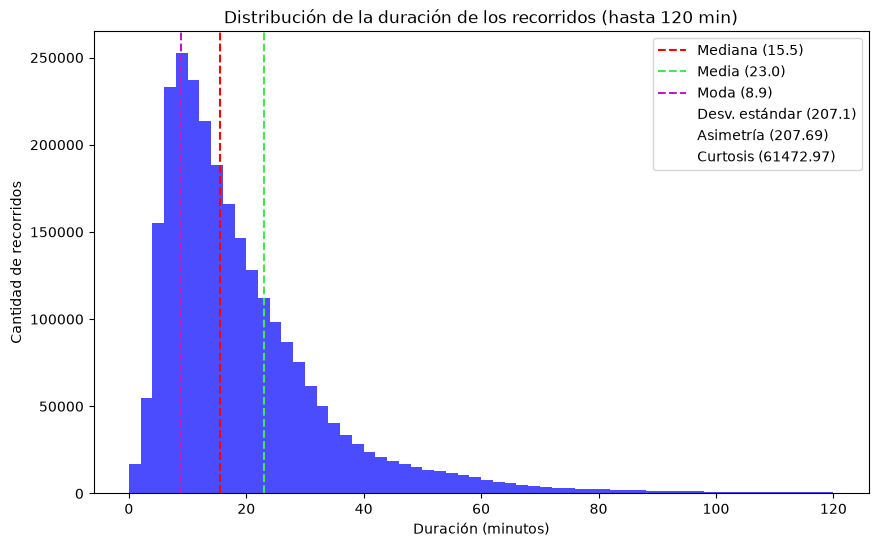

In [25]:
fig, plot = plt.subplots(figsize=(10, 6))

moda = df_recorridos['duracion_recorrido_min'].mode()[0]
mediana = df_recorridos['duracion_recorrido_min'].median()
media = df_recorridos['duracion_recorrido_min'].mean()
skewness = df_recorridos['duracion_recorrido_min'].skew()
curtosis = df_recorridos['duracion_recorrido_min'].kurtosis()

desviacion_estandar = df_recorridos['duracion_recorrido_min'].std()

# se grafica hasta 120 min, esto de sebe a que hay valures muy grandes de recorrido (outliers)
# que hacen que el grafico que inilegible cuando se incluyen
limite_min = 120
plot.hist(df_recorridos['duracion_recorrido_min'], bins=60, range=(0, limite_min), color='blue', alpha=0.7)

plot.axvline(mediana, color='red', linestyle='--', label='Mediana ({:.1f})'.format(mediana))
plot.axvline(df_recorridos['duracion_recorrido_min'].mean(), color="#42E850", linestyle='--', label='Media ({:.1f})'.format(media))
plot.axvline(df_recorridos['duracion_recorrido_min'].mode()[0], color="#c21ac2", linestyle='--', label='Moda ({:.1f})'.format(moda))
plot.plot([], [], ' ', label='Desv. estándar ({:.1f})'.format(desviacion_estandar))
plot.plot([], [], ' ', label='Asimetría ({:.2f})'.format(skewness))
plot.plot([], [], ' ', label='Curtosis ({:.2f})'.format(curtosis))

plot.set_title('Distribución de la duración de los recorridos (hasta 120 min)')
plot.set_xlabel('Duración (minutos)')
plot.set_ylabel('Cantidad de recorridos')
plot.legend()

plt.show()

Vemos que la distribucion de recorridos es prfundamente asimétrica y aparentemente contine muchos outliers en la zona derecha.

In [26]:
# outliers (criterio del rango intercuartílico)
duracion = df_recorridos['duracion_recorrido_min']
Q1 = duracion.quantile(0.25)
Q3 = duracion.quantile(0.75)
IQR = Q3 - Q1

# la duración no puede ser negativa, por lo que el límite inferior se acota en 0
limite_inferior = max(0, Q1 - 1.5 * IQR)
limite_superior = Q3 + 1.5 * IQR

limite_inferior_count = (duracion < limite_inferior).sum()
limite_superior_count = (duracion > limite_superior).sum()

print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Cantidad de recorridos por debajo del límite inferior ({limite_inferior:.2f} min): {limite_inferior_count:,}")
print(f"Cantidad de recorridos por encima del límite superior ({limite_superior:.2f} min): {limite_superior_count:,}")
print(f"Porcentaje de recorridos por debajo del límite inferior: {limite_inferior_count / len(duracion) * 100:.2f}%")
print(f"Porcentaje de recorridos por encima del límite superior: {limite_superior_count / len(duracion) * 100:.2f}%")



Q1: 9.53, Q3: 25.22, IQR: 15.68
Cantidad de recorridos por debajo del límite inferior (0.00 min): 0
Cantidad de recorridos por encima del límite superior (48.74 min): 156,752
Porcentaje de recorridos por debajo del límite inferior: 0.00%
Porcentaje de recorridos por encima del límite superior: 5.98%


In [27]:
print("cantidad de recorridos por encima de 240 minutos: ", (duracion > 120).sum())

cantidad de recorridos por encima de 240 minutos:  19565


In [28]:
# --- A. Cuantitativa discreta (derivada): cantidad de viajes por usuario ---
viajes_por_usuario = df_recorridos.groupby("id_usuario").size().rename("viajes_por_usuario")

print(f"Usuarios distintos con al menos un viaje: {viajes_por_usuario.shape[0]:,}")
viajes_por_usuario.describe().round()


Usuarios distintos con al menos un viaje: 212,068


count    212068.0
mean         12.0
std          32.0
min           1.0
25%           1.0
50%           3.0
75%           8.0
max        1122.0
Name: viajes_por_usuario, dtype: float64

## Creacion de variables

#### Recorridos - crear columna para clasificar duracion

In [29]:
# --- B. Categórica ordinal (derivada): duración agrupada con orden explícito ---
etiquetas_duracion = ["corto", "medio", "largo"]
orden_duracion = CategoricalDtype(categories=etiquetas_duracion, ordered=True)

corto_threshold = df_recorridos["duracion_recorrido_min"].quantile(1 / 3)   # corto:  hasta el primer tercil
medio_threshold = df_recorridos["duracion_recorrido_min"].quantile(2 / 3)   # medio:  hasta el segundo tercil
largo_threshold = float("inf")                                              # largo:  por encima del segundo tercil

print(f"Umbrales: corto <= {corto_threshold:.1f} min | medio <= {medio_threshold:.1f} min | largo > {medio_threshold:.1f} min")

df_recorridos["duracion_categoria"] = pd.cut(
    df_recorridos["duracion_recorrido_min"],
    bins=[-1, corto_threshold, medio_threshold, largo_threshold],
    labels=etiquetas_duracion,
).astype(orden_duracion)

df_recorridos["duracion_categoria"].value_counts().sort_index()


Umbrales: corto <= 11.3 min | medio <= 21.3 min | largo > 21.3 min


duracion_categoria
corto    874828
medio    874385
largo    873116
Name: count, dtype: int64

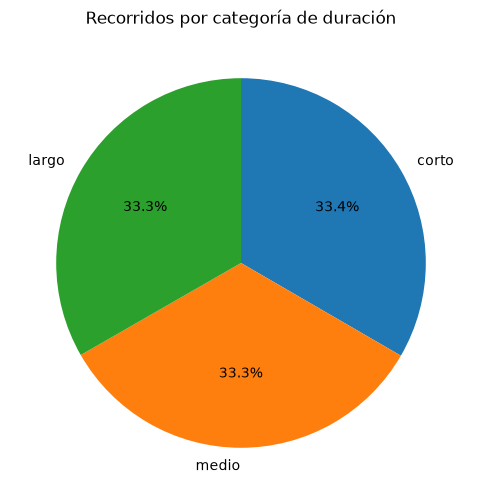

In [45]:
# pie chart: porcentaje de recorridos por categoría de duración
conteo_duracion = df_recorridos["duracion_categoria"].value_counts().sort_index()   # orden: corto, medio, largo

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(conteo_duracion.values, labels=conteo_duracion.index,
       autopct="%1.1f%%", startangle=90, counterclock=False)
ax.set_title("Recorridos por categoría de duración")
plt.show()

#### Otra variable derivada útil: hora del día

In [35]:
# hora, dia y mes de inicio del viaje como numeros (no modifica fecha_origen_recorrido)
df_recorridos["hora_inicio"] = df_recorridos["fecha_origen_recorrido"].dt.hour    # 0-23
df_recorridos["dia_inicio"] = df_recorridos["fecha_origen_recorrido"].dt.dayofweek  # 0-6 (0 = lunes, 6 = domingo)
df_recorridos["mes_inicio"] = df_recorridos["fecha_origen_recorrido"].dt.month    # 1-12

In [36]:
df_recorridos[["Id_recorrido", "hora_inicio", "dia_inicio", "mes_inicio"]].head()

,Id_recorrido,hora_inicio,dia_inicio,mes_inicio
0,17910696BAEcobici,10,0,4
1,17600256BAEcobici,17,2,3
2,17255670BAEcobici,23,2,2
3,17996972BAEcobici,11,2,5
4,17148836BAEcobici,6,0,2


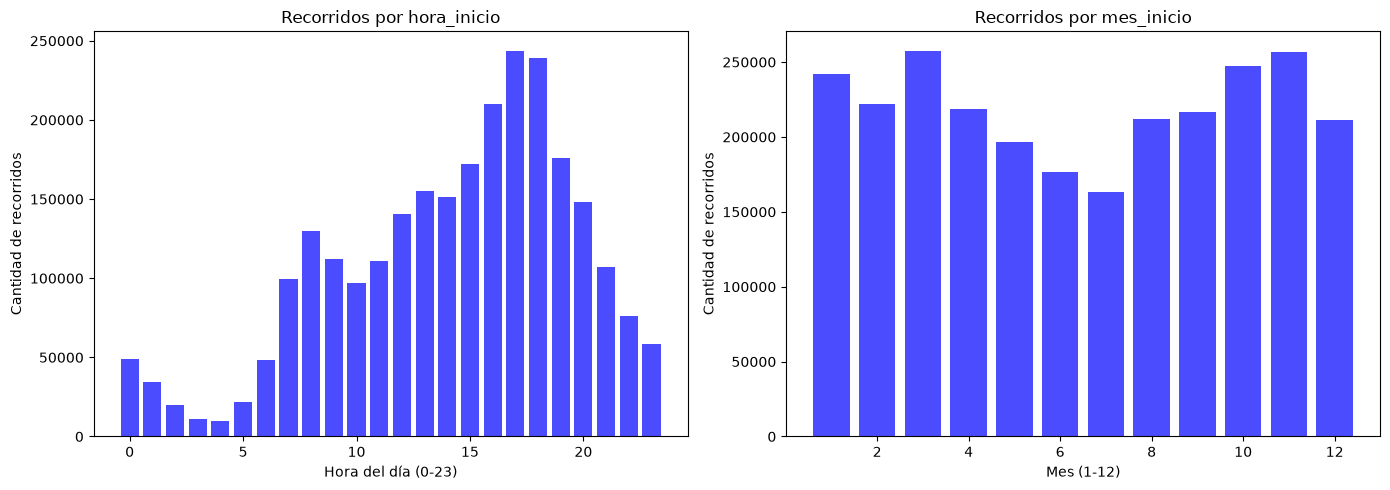

In [41]:
# creat un plot para ver como se distribuye"hora_inicio", "dia_inicio", "mes_inicio"
# barplots: cantidad de recorridos por hora y por mes
variables_bar = {
    "hora_inicio": "Hora del día (0-23)",
    "mes_inicio": "Mes (1-12)",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (columna, etiqueta) in zip(axes, variables_bar.items()):
    conteo = df_recorridos[columna].value_counts().sort_index()   # cantidad de recorridos por valor
    ax.bar(conteo.index, conteo.values, color="blue", alpha=0.7)
    ax.set_title(f"Recorridos por {columna}")
    ax.set_xlabel(etiqueta)
    ax.set_ylabel("Cantidad de recorridos")
plt.tight_layout()
plt.show()

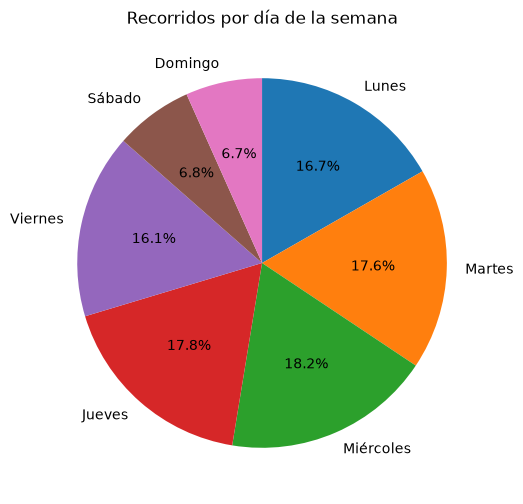

In [43]:
# pie chart: porcentaje de recorridos por día de la semana
nombres_dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
conteo_dias = df_recorridos["dia_inicio"].value_counts().sort_index()   # 0 = lunes, 6 = domingo

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(conteo_dias.values, labels=[nombres_dias[d] for d in conteo_dias.index],
       autopct="%1.1f%%", startangle=90, counterclock=False)
ax.set_title("Recorridos por día de la semana")
plt.show()

#### Cuantitativa discreta: viajes por usuario


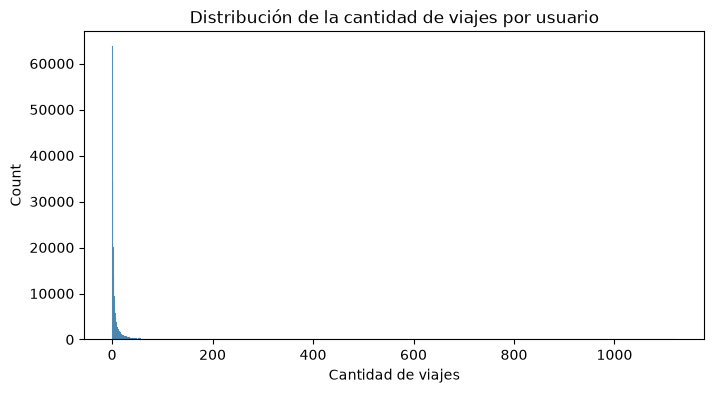

In [46]:
plt.figure(figsize=(8, 4))
sns.histplot(viajes_por_usuario, discrete=True)
plt.title("Distribución de la cantidad de viajes por usuario")
plt.xlabel("Cantidad de viajes")
plt.show()


#### Categóricas nominales: frecuencia de cada categoría



--- genero ---
genero
MALE      60.54
FEMALE    30.29
OTHER      9.17
Name: proportion, dtype: float64

--- modelo_bicicleta ---
modelo_bicicleta
FIT       63.12
ICONIC    36.88
Name: proportion, dtype: float64


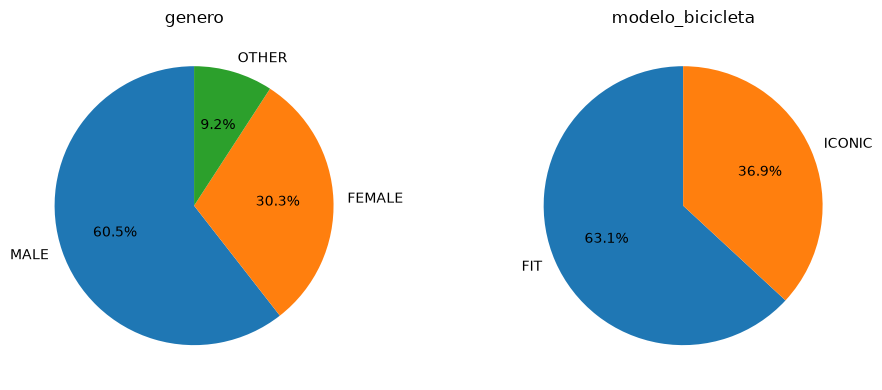

In [47]:
for col in ["genero", "modelo_bicicleta"]:
    print(f"\n--- {col} ---")
    print((df_recorridos[col].value_counts(normalize=True) * 100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
genero_counts = df_recorridos["genero"].value_counts()
modelo_counts = df_recorridos["modelo_bicicleta"].value_counts()
axes[0].pie(genero_counts, labels=genero_counts.index, autopct="%1.1f%%", startangle=90)
axes[0].set_title("genero")
axes[1].pie(modelo_counts, labels=modelo_counts.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("modelo_bicicleta")
plt.tight_layout()
plt.show()


#### Categórica ordinal: duración agrupada (respeta el orden corto < medio < largo)


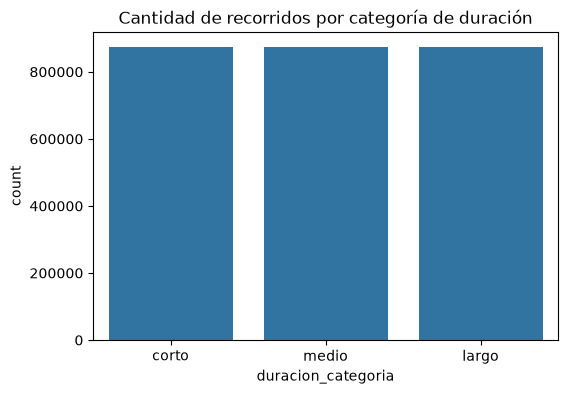

In [48]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_recorridos, x="duracion_categoria", order=etiquetas_duracion)
plt.title("Cantidad de recorridos por categoría de duración")
plt.show()
